# Parameter-Based Curve Reconstruction (Leave-One-Out)

> **Authors:** Davide Corso, Marco Soldani  
> **Context:** Analysis of Galvanostatic Electrochemical Impedance Spectroscopy (GEIS) data on Lithium-Ion batteries (LiCoO₂).

This work is based on the research paper: *"Hysteresis Phenomenon in the Electric Parameters of Lithium-Ion Batteries under Temperature Effects"* (gruppo di ricerca del Politecnico di Milano, THERMINIC 2025).

### Dataset Overview
* **Scope:** 5 Agings (aging states) × 8 Temperatures × 5 SOC levels.
* **Total Data:** 40 unique Nyquist plots.
* **Objective:** Perform a **Leave-One-Out** cross-validation by excluding one specific *Aging × Temperature* combination. The goal is to train models on the remaining 39 combinations to accurately predict the 40th (unseen) plot.


# 1. Setup

In [1]:
import sys
assert sys.version_info >= (3, 5), "Python 3.5+ is required"

# --- STANDARD LIBRARIES ---
import warnings
import time

# --- SCIENTIFIC LIBRARIES ---
import numpy as np
import pandas as pd

# --- VISUALIZATION ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- MACHINE LEARNING ---
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    BaggingRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- CONFIGURATION ---
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
mpl.rc("axes", labelsize=13)
mpl.rc("xtick", labelsize=11)
mpl.rc("ytick", labelsize=11)
mpl.rc("legend", fontsize=10)
mpl.rc("figure", dpi=120)

# --- CONSTANTS ---
TEMP_COLORS = {
    20.0: "#1b9e77",
    22.5: "#d95f02",
    25.0: "#7570b3",
    27.5: "#e7298a",
    30.0: "#66a61e",
    35.0: "#e6ab02",
    40.0: "#a6761d",
    47.5: "#666666",
}

AGING_LABELS = {
    0: "Aging 0 (Fresh)",
    1: "Aging 1",
    2: "Aging 2",
    3: "Aging 3",
    4: "Aging 4 (Aged)",
}

SOC_MARKERS = {
    0: "o",
    1: "s",
    2: "^",
    3: "D",
    4: "v",
}

TEMPS_SORTED = sorted(TEMP_COLORS.keys())
AGINGS = list(AGING_LABELS.keys())

# --- ENVIRONMENT INFO ---
def print_environment_info():
    import sklearn

    print("Setup completed")
    print(
        f"Python {sys.version_info.major}.{sys.version_info.minor} | "
        f"NumPy {np.__version__} | "
        f"Pandas {pd.__version__} | "
        f"Scikit-learn {sklearn.__version__}"
    )


print_environment_info()

Setup completed
Python 3.12 | NumPy 2.0.1 | Pandas 2.3.3 | Scikit-learn 1.7.1


# 2. Data Loading

In [2]:
import pandas as pd
from pathlib import Path

try:
    current_dir = Path(__file__).resolve().parent
except NameError:
    import os
    current_dir = Path(os.getcwd())

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

file_path = project_root / "data" / "processed" / "batteries_cleaned_dataset.csv"
print(f"Looking for file at: {file_path}")

if not file_path.exists():
    raise FileNotFoundError(f"CSV file not found at: {file_path}")

df = pd.read_csv(file_path)

def print_dataset_summary(df):
    print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"Agings: {sorted(df['Aging'].unique().tolist())} | "
          f"Temperatures: {sorted(df['Temperature'].unique().tolist())}°C")
    print(f"SOC levels: {sorted(df['SOC'].unique().tolist())} | "
          f"Frequency range: {df['Frequency'].min():.2f}–{df['Frequency'].max():.0f} Hz")
    print(f"Aging × Temperature combinations: "
          f"{df.groupby(['Aging', 'Temperature']).ngroups}")
    
print_dataset_summary(df)
df.head(10)

Looking for file at: /Users/davidecorso/Desktop/SUPSI/Progetto_Semestre/git/ml_LiBs_project/data/processed/batteries_cleaned_dataset.csv
Dataset: 9,805 rows × 6 columns
Agings: [0, 1, 2, 3, 4] | Temperatures: [20.0, 22.5, 25.0, 27.5, 30.0, 35.0, 40.0, 47.5]°C
SOC levels: [0, 1, 2, 3, 4] | Frequency range: 0.10–10002 Hz
Aging × Temperature combinations: 40


,Aging,Temperature,SOC,Frequency,Z_real,Z_imag
0,0,20.0,0,10002.2290,3.004527,-0.916100
1,0,20.0,0,7904.9590,2.971508,-0.661783
2,0,20.0,0,6248.7827,3.047303,-0.422141
3,0,20.0,0,4941.5811,3.100461,-0.164312
4,0,20.0,0,3906.2498,3.172908,-0.012017
5,0,20.0,0,3087.0369,3.247350,0.125193
6,0,20.0,0,2440.7808,3.340029,0.239525
7,0,20.0,0,1930.6177,3.418471,0.317611
8,0,20.0,0,1525.4882,3.508611,0.390777
9,0,20.0,0,1206.9312,3.598584,0.455021


# 3. Exploratory Data Analysis (EDA)

In [3]:
# 3.1 Descriptive statistics
print("=== DESCRIPTIVE STATISTICS ===\n")
print(df.describe().round(4).to_string())

=== DESCRIPTIVE STATISTICS ===

           Aging  Temperature        SOC   Frequency     Z_real     Z_imag
count  9805.0000    9805.0000  9805.0000   9805.0000  9805.0000  9805.0000
mean      2.0010      30.9319     2.0000    974.0061     4.1713     0.3392
std       1.4146       8.7461     1.4143   2119.3246     1.5224     0.3910
min       0.0000      20.0000     0.0000      0.0999     1.6747    -1.3053
25%       1.0000      22.5000     1.0000      2.1230     3.0491     0.1436
50%       2.0000      27.5000     2.0000     35.5575     3.8333     0.2858
75%       3.0000      35.0000     3.0000    596.7186     4.9928     0.5070
max       4.0000      47.5000     4.0000  10002.2290    13.0745     2.6160


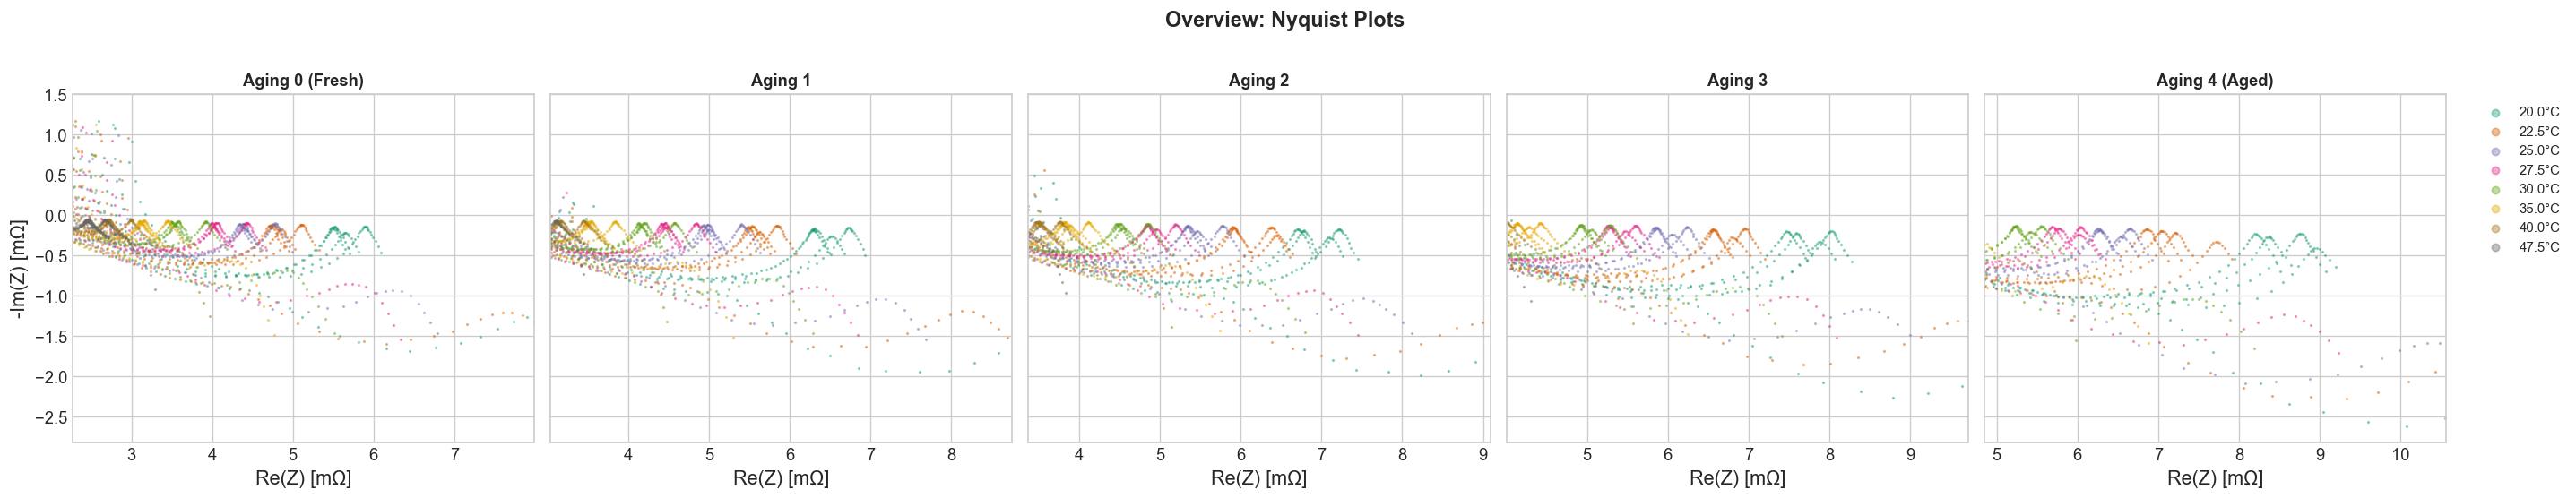

In [4]:
# 3.2 Nyquist plot overview by Aging and Temperature
fig, axes = plt.subplots(1, 5, figsize=(24, 4.5), sharey=True)

for aging in range(5):
    ax = axes[aging]
    subset = df[df["Aging"] == aging]

    for temp in TEMPS_SORTED:
        mask = subset["Temperature"] == temp
        ax.scatter(
            subset.loc[mask, "Z_real"],
            -subset.loc[mask, "Z_imag"],
            s=1,
            alpha=0.4,
            color=TEMP_COLORS[temp],
            label=f"{temp}°C"
        )

    ax.set_xlabel("Re(Z) [mΩ]")
    
    if aging == 0:
        ax.set_ylabel("-Im(Z) [mΩ]")

    ax.set_title(AGING_LABELS[aging], fontsize=11, fontweight="bold")
    ax.set_aspect("equal", adjustable="datalim")

# Legend and title
axes[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    markerscale=5,
    fontsize=9
)

fig.suptitle(
    "Overview: Nyquist Plots",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

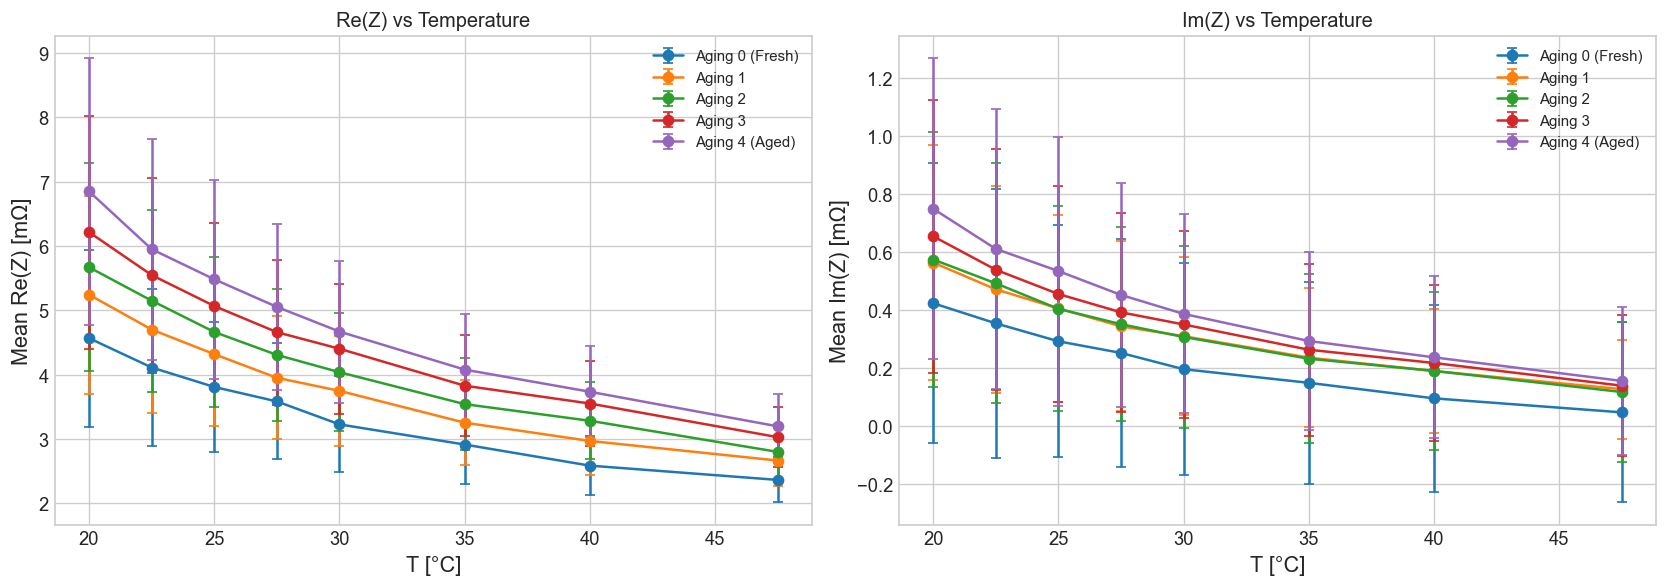

In [5]:
# 3.3 Impedance vs Temperature trend
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for aging in range(5):
    subset = df[df["Aging"] == aging]

    for ax_idx, (col, label) in enumerate([("Z_real", "Re(Z)"), ("Z_imag", "Im(Z)")]):
        means = subset.groupby("Temperature")[col].mean()
        stds = subset.groupby("Temperature")[col].std()

        axes[ax_idx].errorbar(
            means.index,
            means.values,
            yerr=stds.values,
            marker="o",
            label=AGING_LABELS[aging],
            capsize=3
        )

# Axis configuration
axes[0].set_xlabel("T [°C]")
axes[0].set_ylabel("Mean Re(Z) [mΩ]")
axes[0].set_title("Re(Z) vs Temperature")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("T [°C]")
axes[1].set_ylabel("Mean Im(Z) [mΩ]")
axes[1].set_title("Im(Z) vs Temperature")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# 4. Selection of the Combination to Exclude

> **Mode:**
> - `mode = 'random'` → randomly select an Aging and Temperature  
> - `mode = 'manual'` → specify `MANUAL_AGING` and `MANUAL_TEMP` in the cells below  
>
> The selected combination is **completely removed** from the training set.  
> Its real data is used only for final validation.

In [6]:
# CONFIGURATION: Choose the selection mode 
mode = 'random'           # 'random' or 'manual'
RANDOM_SEED = 42          # Seed for reproducible random selection. Change it to get a different combination.

# If mode = 'manual', specify here:
MANUAL_AGING = 2          # Aging to exclude (0, 1, 2, 3, 4)
MANUAL_TEMP  = 22.5       # Temperature to exclude (20.0, 22.5, 25.0, 27.5, 30.0, 35.0, 40.0, 47.5)

if mode == 'manual':
    assert MANUAL_AGING in AGINGS, f"Invalid Aging {MANUAL_AGING}. Valid values: {AGINGS}"
    assert MANUAL_TEMP in TEMPS_SORTED, f"Invalid Temperature {MANUAL_TEMP}. Valid values: {TEMPS_SORTED}"
    EXCLUDED_AGING = MANUAL_AGING
    EXCLUDED_TEMP = MANUAL_TEMP
    print("   MANUAL mode selected")
elif mode == 'random':
    np.random.seed(RANDOM_SEED)
    EXCLUDED_AGING = np.random.choice(AGINGS)
    EXCLUDED_TEMP = np.random.choice(TEMPS_SORTED)
    print(f"   RANDOM mode selected (seed={RANDOM_SEED})")
else:
    raise ValueError(f"Mode '{mode}' not recognized. Use 'random' or 'manual'.")

print(f"   Excluded combination: Aging {EXCLUDED_AGING}, {EXCLUDED_TEMP}°C")

# --- Split dataset ---
mask_excluded = (df['Aging'] == EXCLUDED_AGING) & (df['Temperature'] == EXCLUDED_TEMP)
df_train = df[~mask_excluded].copy()
df_test = df[mask_excluded].copy()

print(f"   Training: {len(df_train):,} points "
      f"({df.groupby(['Aging','Temperature']).ngroups - 1} combinations)")
print(f"   Test:     {len(df_test):,} points "
      f"(1 combination, {df_test['SOC'].nunique()} SOC × {len(df_test)//df_test['SOC'].nunique()} frequencies)")

   RANDOM mode selected (seed=42)
   Excluded combination: Aging 3, 30.0°C
   Training: 9,560 points (39 combinations)
   Test:     245 points (1 combination, 5 SOC × 49 frequencies)


# 5. Generation of the 39 Nyquist Plots

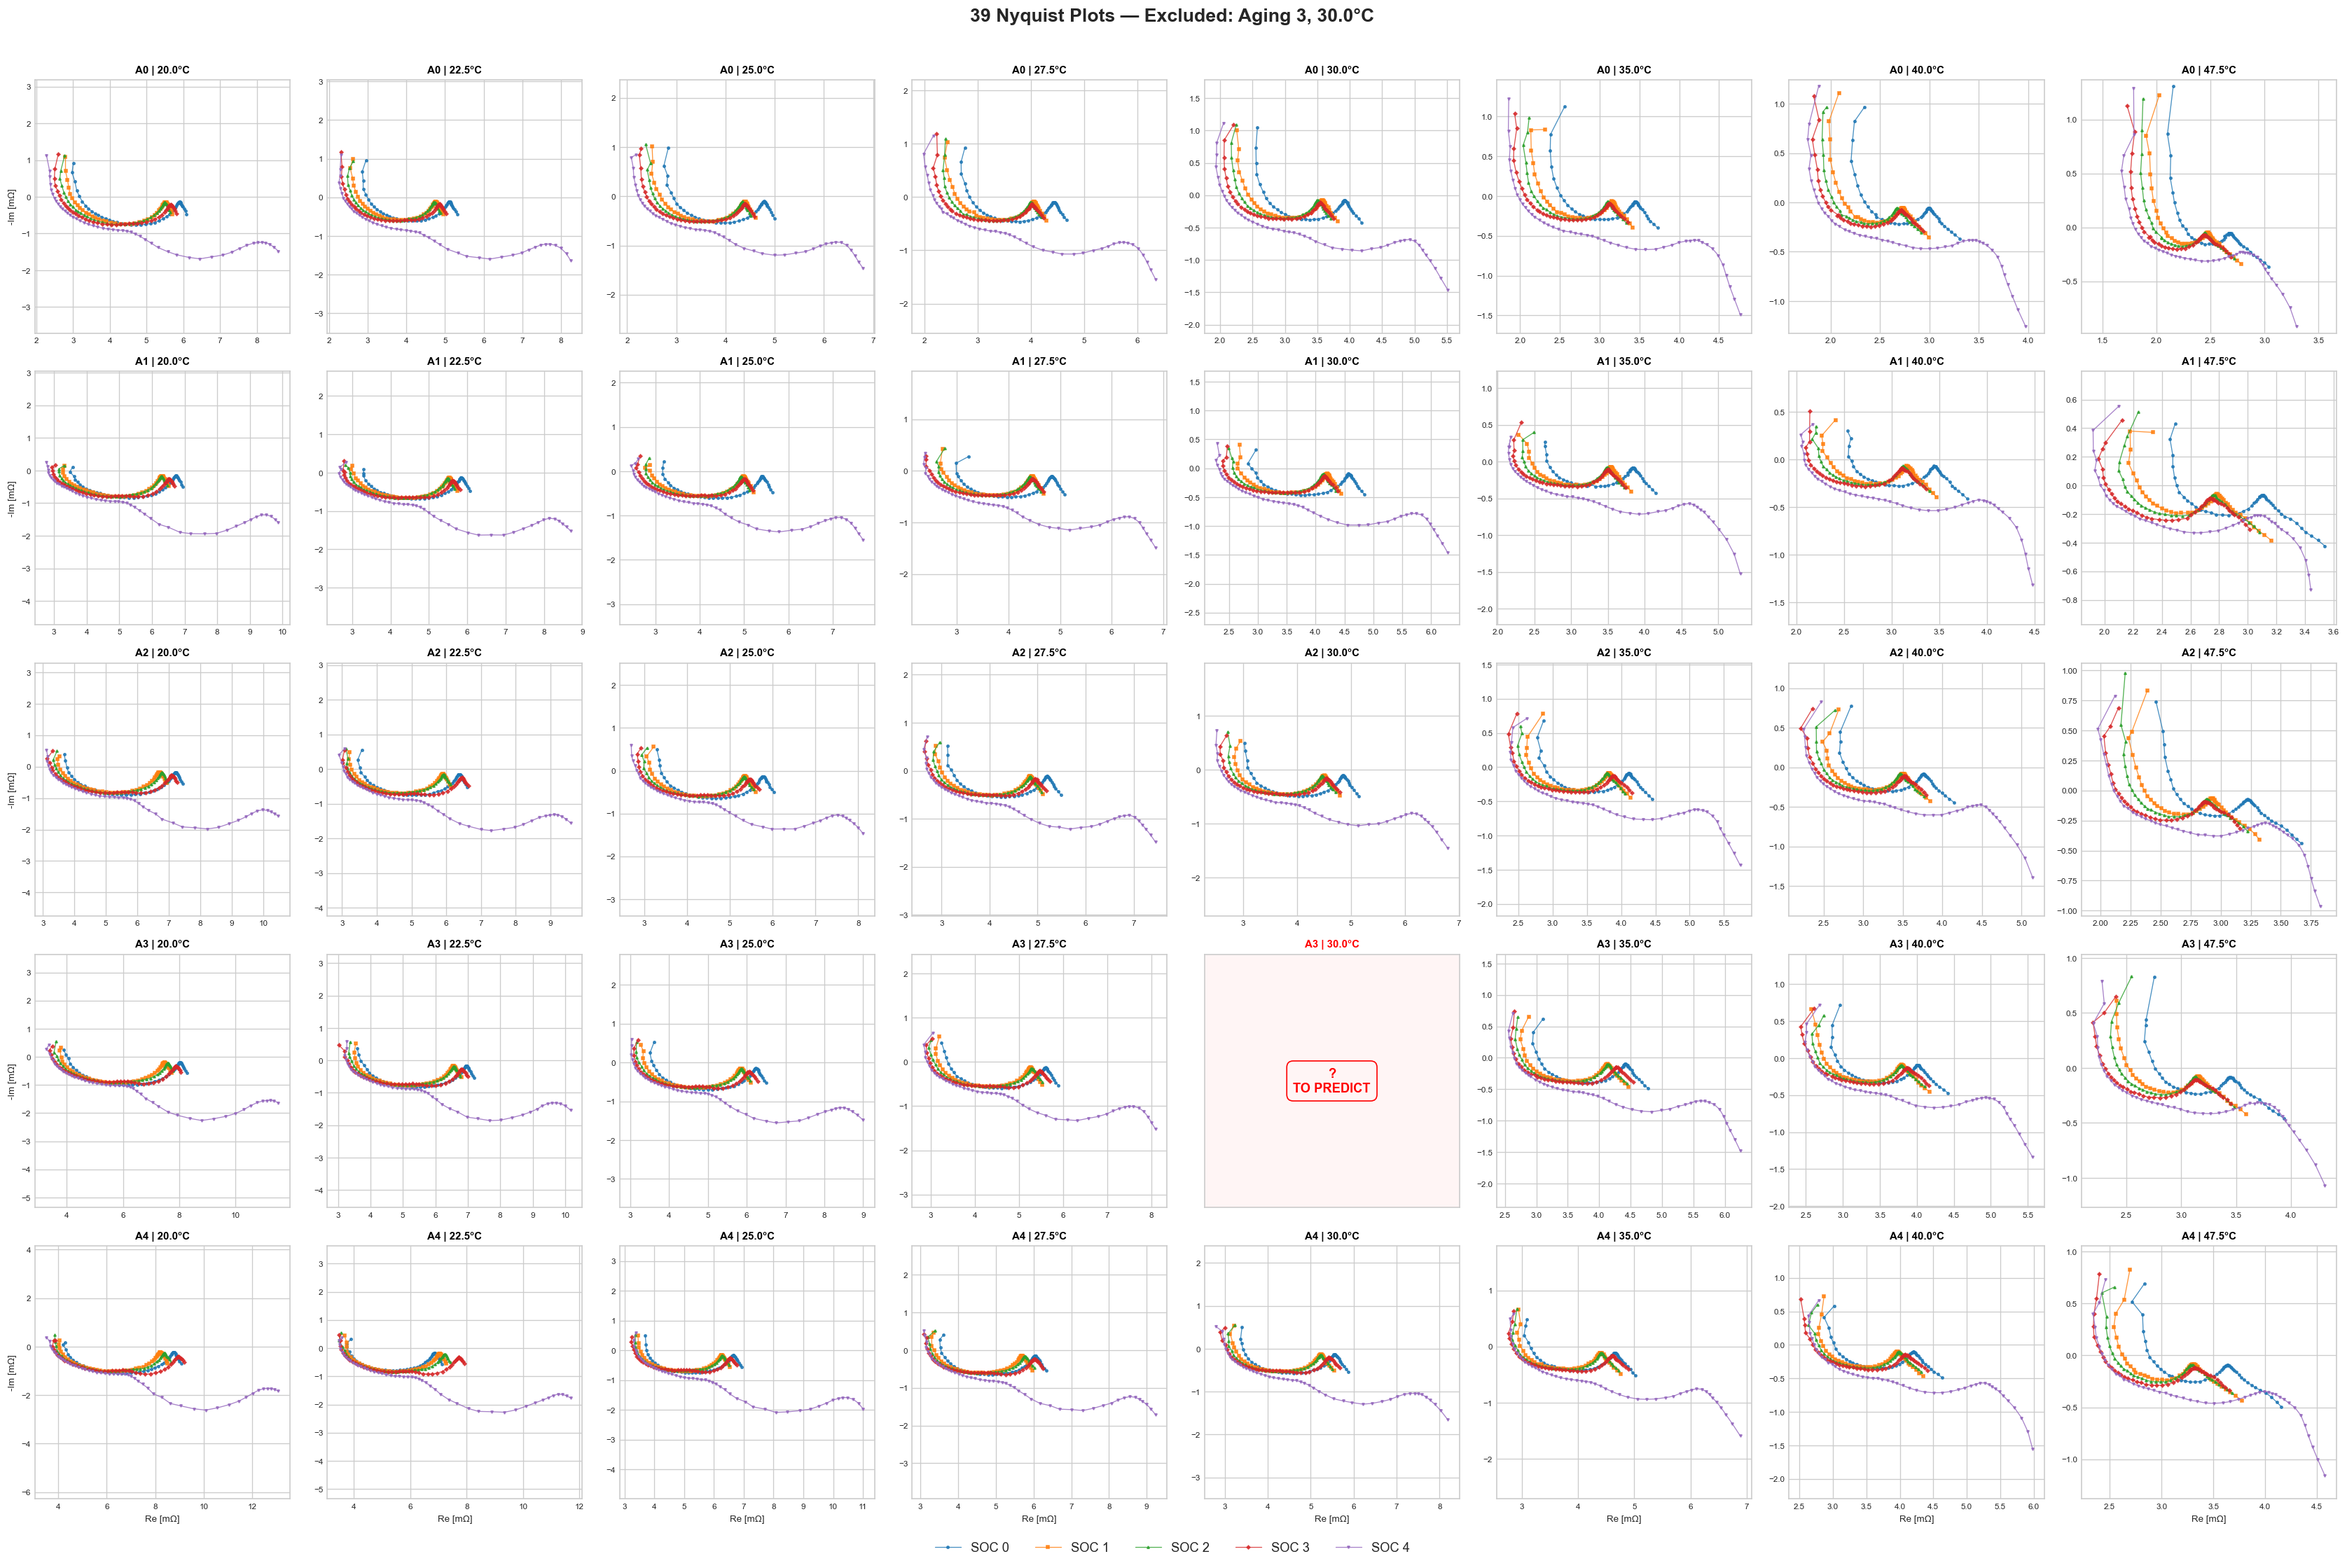

In [7]:
fig, axes = plt.subplots(5, 8, figsize=(28, 18))

for i, aging in enumerate(AGINGS):
    for j, temp in enumerate(TEMPS_SORTED):
        ax = axes[i][j]
        is_excluded = (aging == EXCLUDED_AGING and temp == EXCLUDED_TEMP)

        if is_excluded:
            ax.text(
                0.5, 0.5, '?\nTO PREDICT',
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='red',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff5f5', edgecolor='red')
            )
            ax.set_facecolor('#fff5f5')
            ax.set_xticks([]); ax.set_yticks([])
        else:
            subset = df[(df['Aging'] == aging) & (df['Temperature'] == temp)]
            for soc in sorted(subset['SOC'].unique()):
                sd = subset[subset['SOC'] == soc]
                ax.plot(
                    sd['Z_real'], -sd['Z_imag'],
                    marker=SOC_MARKERS[soc],
                    markersize=2,
                    linewidth=0.8,
                    alpha=0.8,
                    label=f'SOC {soc}' if i == 0 and j == 0 else ''
                )
            ax.set_aspect('equal', adjustable='datalim')

        if i == 4: ax.set_xlabel('Re [mΩ]', fontsize=8)
        if j == 0: ax.set_ylabel('-Im [mΩ]', fontsize=8)
        title_color = 'red' if is_excluded else 'black'
        ax.set_title(f'A{aging} | {temp}°C', fontsize=9, fontweight='bold', color=title_color)
        ax.tick_params(labelsize=7)

# Create legend
handles, labels = None, None
for ax_row in axes:
    for ax in ax_row:
        h, l = ax.get_legend_handles_labels()
        if h: 
            handles, labels = h[:5], [f'SOC {i}' for i in range(5)]
            break
    if handles: break

if handles:
    fig.legend(
        handles, labels,
        loc='lower center',
        ncol=5,
        fontsize=11,
        bbox_to_anchor=(0.5, -0.02)
    )

fig.suptitle(
    f'39 Nyquist Plots — Excluded: Aging {EXCLUDED_AGING}, {EXCLUDED_TEMP}°C',
    fontsize=16, fontweight='bold', y=1.01
)

plt.tight_layout()
plt.show()

# 6. Feature Engineering

In [8]:
def build_features(data):
    X = pd.DataFrame({
        'Aging':       data['Aging'].values,
        'Temperature': data['Temperature'].values,
        'SOC':         data['SOC'].values,
        'Frequency':   data['Frequency'].values,
        'log_Freq':    np.log10(data['Frequency'].values),
        'Aging_x_Temp': data['Aging'].values * data['Temperature'].values,
        'SOC_x_Temp':   data['SOC'].values * data['Temperature'].values,
        'SOC_x_Aging':  data['SOC'].values * data['Aging'].values,
        'inv_Temp':     1.0 / (data['Temperature'].values + 273.15),
    })
    return X

X_train = build_features(df_train)
y_train = df_train[['Z_real', 'Z_imag']].values
X_test = build_features(df_test)
y_test = df_test[['Z_real', 'Z_imag']].values

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train)

print(f"Features ({X_train.shape[1]}): {list(X_train.columns)}")

Features (9): ['Aging', 'Temperature', 'SOC', 'Frequency', 'log_Freq', 'Aging_x_Temp', 'SOC_x_Temp', 'SOC_x_Aging', 'inv_Temp']


# 7. Multi-Model Training

> We compare 5 models of increasing complexity:
>
> | Model | Type | Characteristic |
> |---|---|---|
> | Ridge Regression | Linear | Baseline with L2 regularization |
> | Random Forest | Ensemble (bagging) | Decision trees with bootstrap |
> | Gradient Boosting | Ensemble (boosting) | Iterative error correction |
> | K-Nearest Neighbors | Instance-based | Prediction by local similarity |
> | Bagging (Ridge) | Ensemble (bagging) | Variance reduction on a linear model |

In [9]:
# --- DEFINE MODELS ---
models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )
    ),
    "K-Nearest Neighbors": KNeighborsRegressor(
        n_neighbors=10,
        weights="distance"
    ),
    "Bagging (Ridge)": BaggingRegressor(
        estimator=Ridge(alpha=1.0),
        n_estimators=30,
        max_samples=0.8,
        random_state=42
    ),
}

# --- TRAINING AND EVALUATION ---
results = []
predictions = {}

print("=== TRAINING AND EVALUATION ===\n")
print(f"{'Model':<25s} {'R²':>8s} {'MSE':>10s} {'MAE':>8s} {'Time':>7s}")
print("─" * 62)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train_s)
    y_pred_s = model.predict(X_test_s)
    y_pred = scaler_y.inverse_transform(y_pred_s)
    dt = time.time() - t0

    predictions[name] = y_pred

    # Metrics per component
    mse_r = mean_squared_error(y_test[:, 0], y_pred[:, 0])
    mse_i = mean_squared_error(y_test[:, 1], y_pred[:, 1])
    mae_r = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
    mae_i = mean_absolute_error(y_test[:, 1], y_pred[:, 1])
    r2_r = r2_score(y_test[:, 0], y_pred[:, 0])
    r2_i = r2_score(y_test[:, 1], y_pred[:, 1])

    # Aggregate results
    results.append({
        "Model": name,
        "MSE_total": (mse_r + mse_i) / 2,
        "MAE_total": (mae_r + mae_i) / 2,
        "R2_total": (r2_r + r2_i) / 2,
        "R2_real": r2_r,
        "R2_imag": r2_i,
        "Time_s": dt
    })

    print(f"{name:<25s} {(r2_r+r2_i)/2:>8.4f} "
          f"{(mse_r+mse_i)/2:>10.6f} "
          f"{(mae_r+mae_i)/2:>8.4f} "
          f"{dt:>6.1f}s")

# Summary
results_df = pd.DataFrame(results).sort_values("MSE_total")
best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest model: {best_model_name} "
      f"(R²={results_df.iloc[0]['R2_total']:.4f})")

=== TRAINING AND EVALUATION ===

Model                           R²        MSE      MAE    Time
──────────────────────────────────────────────────────────────
Ridge Regression            0.6858   0.119977   0.2501    0.0s
Random Forest               0.9141   0.076903   0.1954    0.1s


Gradient Boosting           0.9859   0.010122   0.0697    1.1s
K-Nearest Neighbors         0.9351   0.043658   0.1623    0.0s
Bagging (Ridge)             0.6849   0.120547   0.2519    0.0s

Best model: Gradient Boosting (R²=0.9859)


# 8. Model Comparison

In [10]:
# 8.1 Summary Table
print("=== RANKING (by MSE) ===\n")

display_df = results_df[['Model','MSE_total','MAE_total','R2_total','R2_real','R2_imag','Time_s']].copy()
display_df.columns = ['Model','MSE','MAE','R²','R²(Re)','R²(Im)','Time(s)']

print(display_df.to_string(index=False, float_format='{:.4f}'.format))

=== RANKING (by MSE) ===

              Model    MSE    MAE     R²  R²(Re)  R²(Im)  Time(s)
  Gradient Boosting 0.0101 0.0697 0.9859  0.9810  0.9908   1.1192
K-Nearest Neighbors 0.0437 0.1623 0.9351  0.9191  0.9512   0.0037
      Random Forest 0.0769 0.1954 0.9141  0.8510  0.9772   0.1347
   Ridge Regression 0.1200 0.2501 0.6858  0.8084  0.5633   0.0035
    Bagging (Ridge) 0.1205 0.2519 0.6849  0.8073  0.5625   0.0222


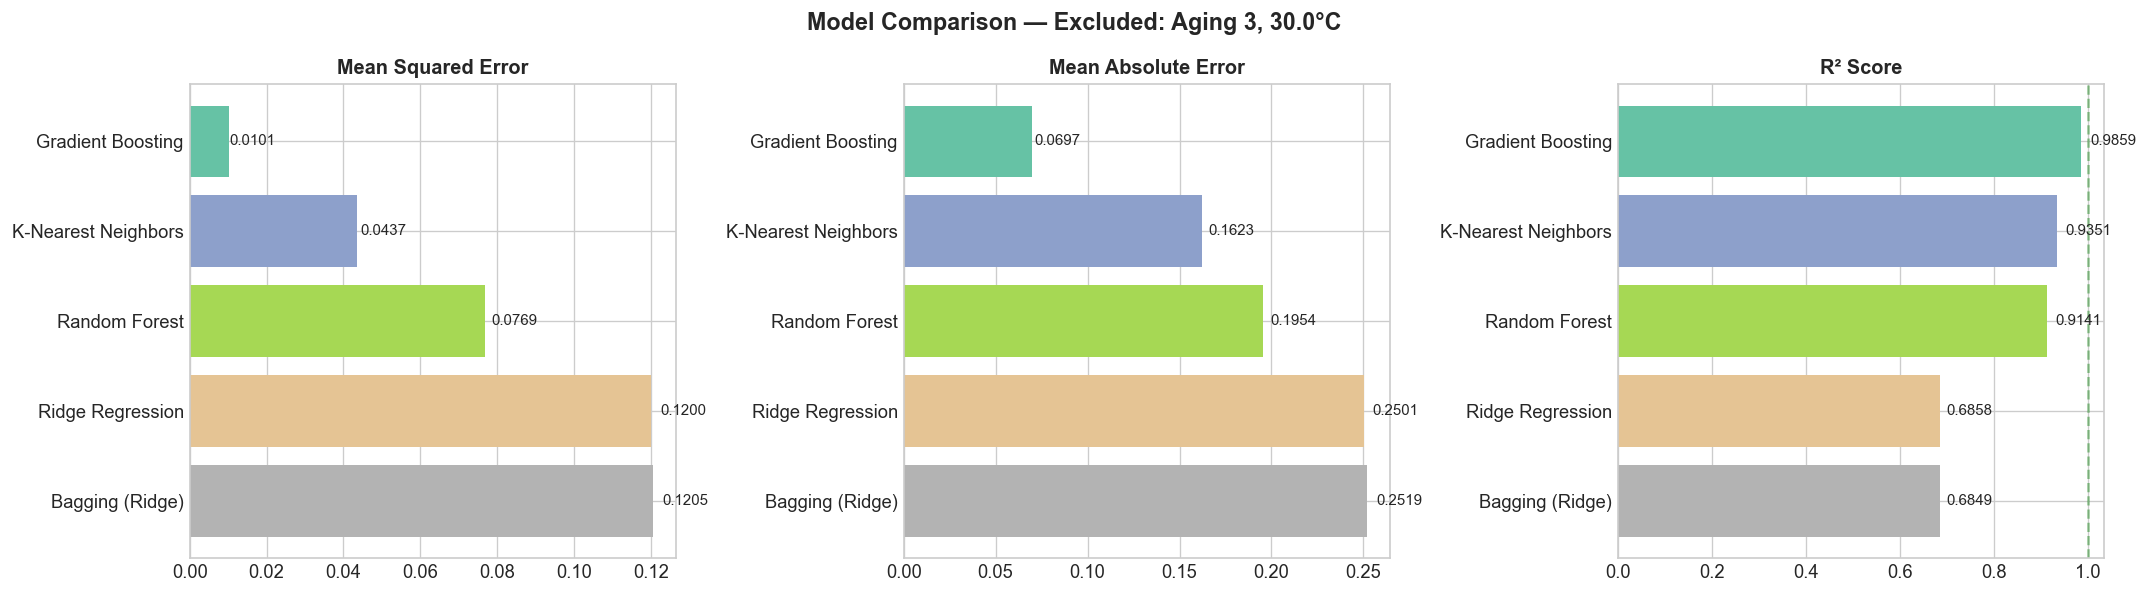

In [11]:
# 8.2 Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

metrics = [
    ('MSE_total', 'Mean Squared Error'),
    ('MAE_total', 'Mean Absolute Error'),
    ('R2_total', 'R² Score')
]

for ax, (col, title) in zip(axes, metrics):
    vals = results_df[col].values
    bars = ax.barh(results_df['Model'].values, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.invert_yaxis()
    
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_width() * 1.02,
            bar.get_y() + bar.get_height()/2,
            f'{v:.4f}',
            va='center',
            fontsize=9
        )
    
    if col == 'R2_total':
        ax.axvline(x=1.0, color='green', linestyle='--', alpha=0.4)

fig.suptitle(
    f'Model Comparison — Excluded: Aging {EXCLUDED_AGING}, {EXCLUDED_TEMP}°C',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 9. Prediction Visualization

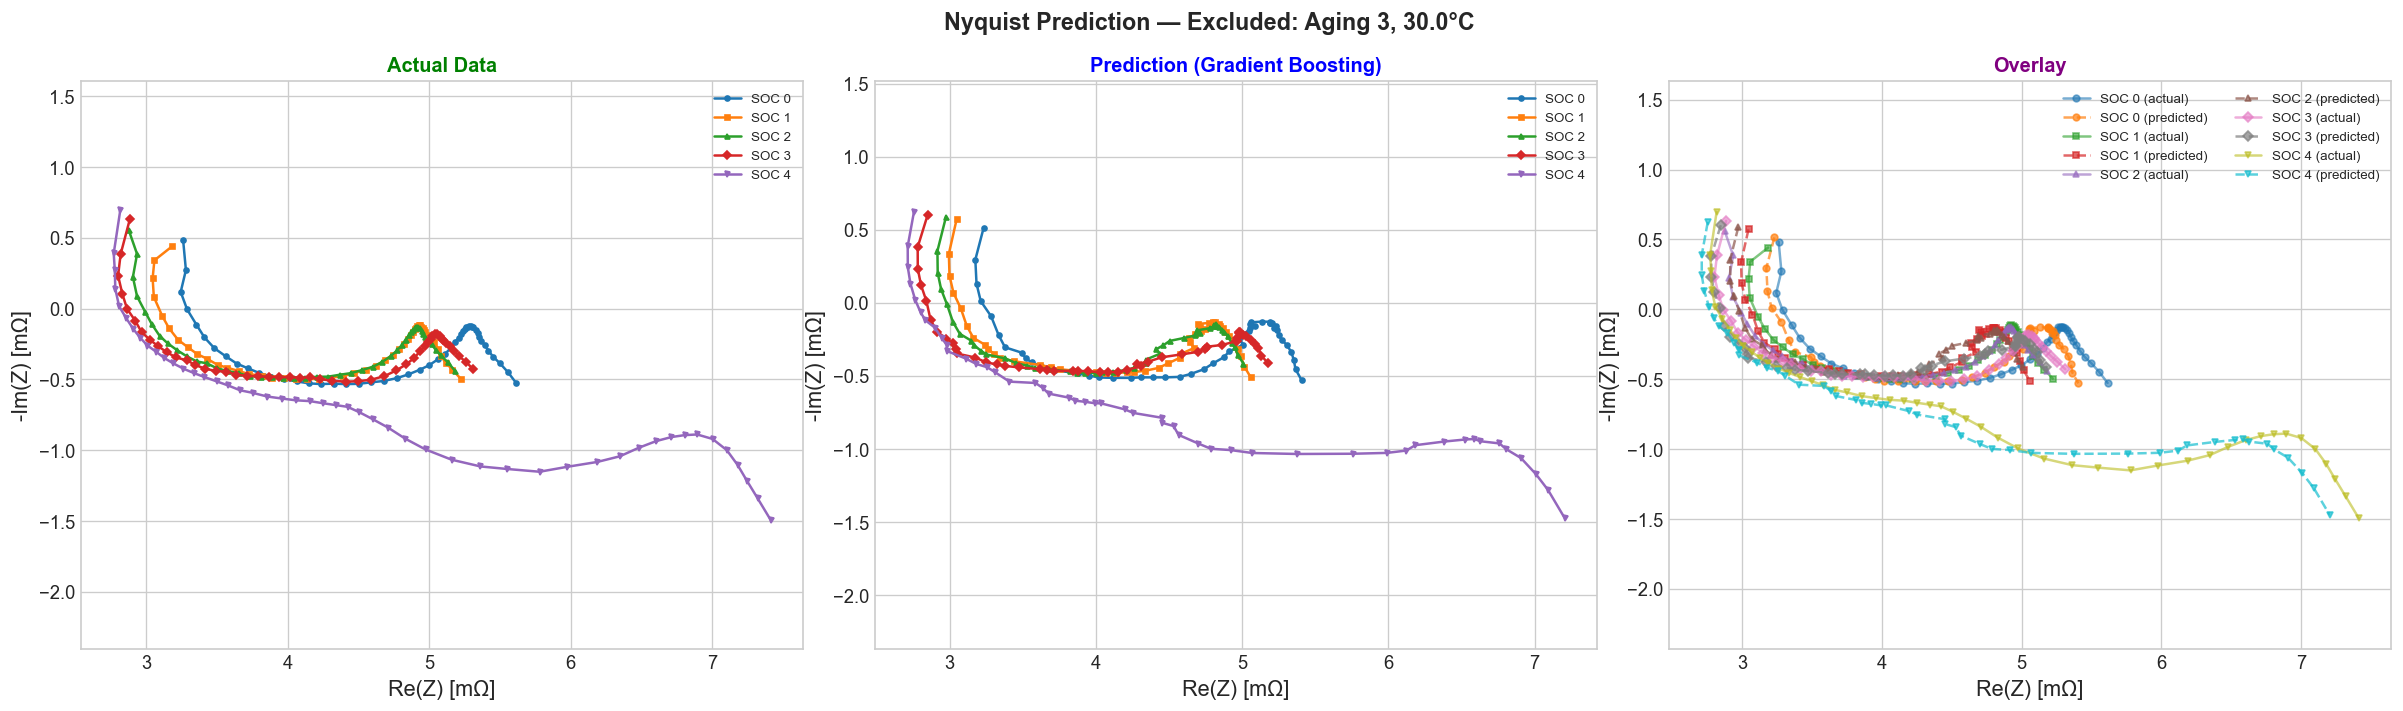

In [12]:
# 9.1 Best Model: Actual vs Predicted vs Overlay
best_pred = predictions[best_model_name]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

soc_list = sorted(df_test['SOC'].unique())
for soc in soc_list:
    mask = df_test['SOC'].values == soc
    # Actual data
    axes[0].plot(
        y_test[mask, 0], -y_test[mask, 1],
        marker=SOC_MARKERS[soc], markersize=3, label=f'SOC {soc}'
    )
    # Predicted data
    axes[1].plot(
        best_pred[mask, 0], -best_pred[mask, 1],
        marker=SOC_MARKERS[soc], markersize=3, label=f'SOC {soc}'
    )
    # Overlay
    axes[2].plot(
        y_test[mask, 0], -y_test[mask, 1],
        marker=SOC_MARKERS[soc], markersize=4, alpha=0.6,
        linewidth=1.5, label=f'SOC {soc} (actual)'
    )
    axes[2].plot(
        best_pred[mask, 0], -best_pred[mask, 1],
        marker=SOC_MARKERS[soc], markersize=4,
        linestyle='--', alpha=0.7, linewidth=1.5, label=f'SOC {soc} (predicted)'
    )

# Configure axes
for ax, title, color in zip(
    axes,
    ['Actual Data', f'Prediction ({best_model_name})', 'Overlay'],
    ['green', 'blue', 'purple']
):
    ax.set_xlabel('Re(Z) [mΩ]')
    ax.set_ylabel('-Im(Z) [mΩ]')
    ax.set_title(title, fontweight='bold', color=color)
    ax.legend(fontsize=8, ncol=2 if 'Overlay' in title else 1)
    ax.set_aspect('equal', adjustable='datalim')

fig.suptitle(
    f'Nyquist Prediction — Excluded: Aging {EXCLUDED_AGING}, {EXCLUDED_TEMP}°C',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

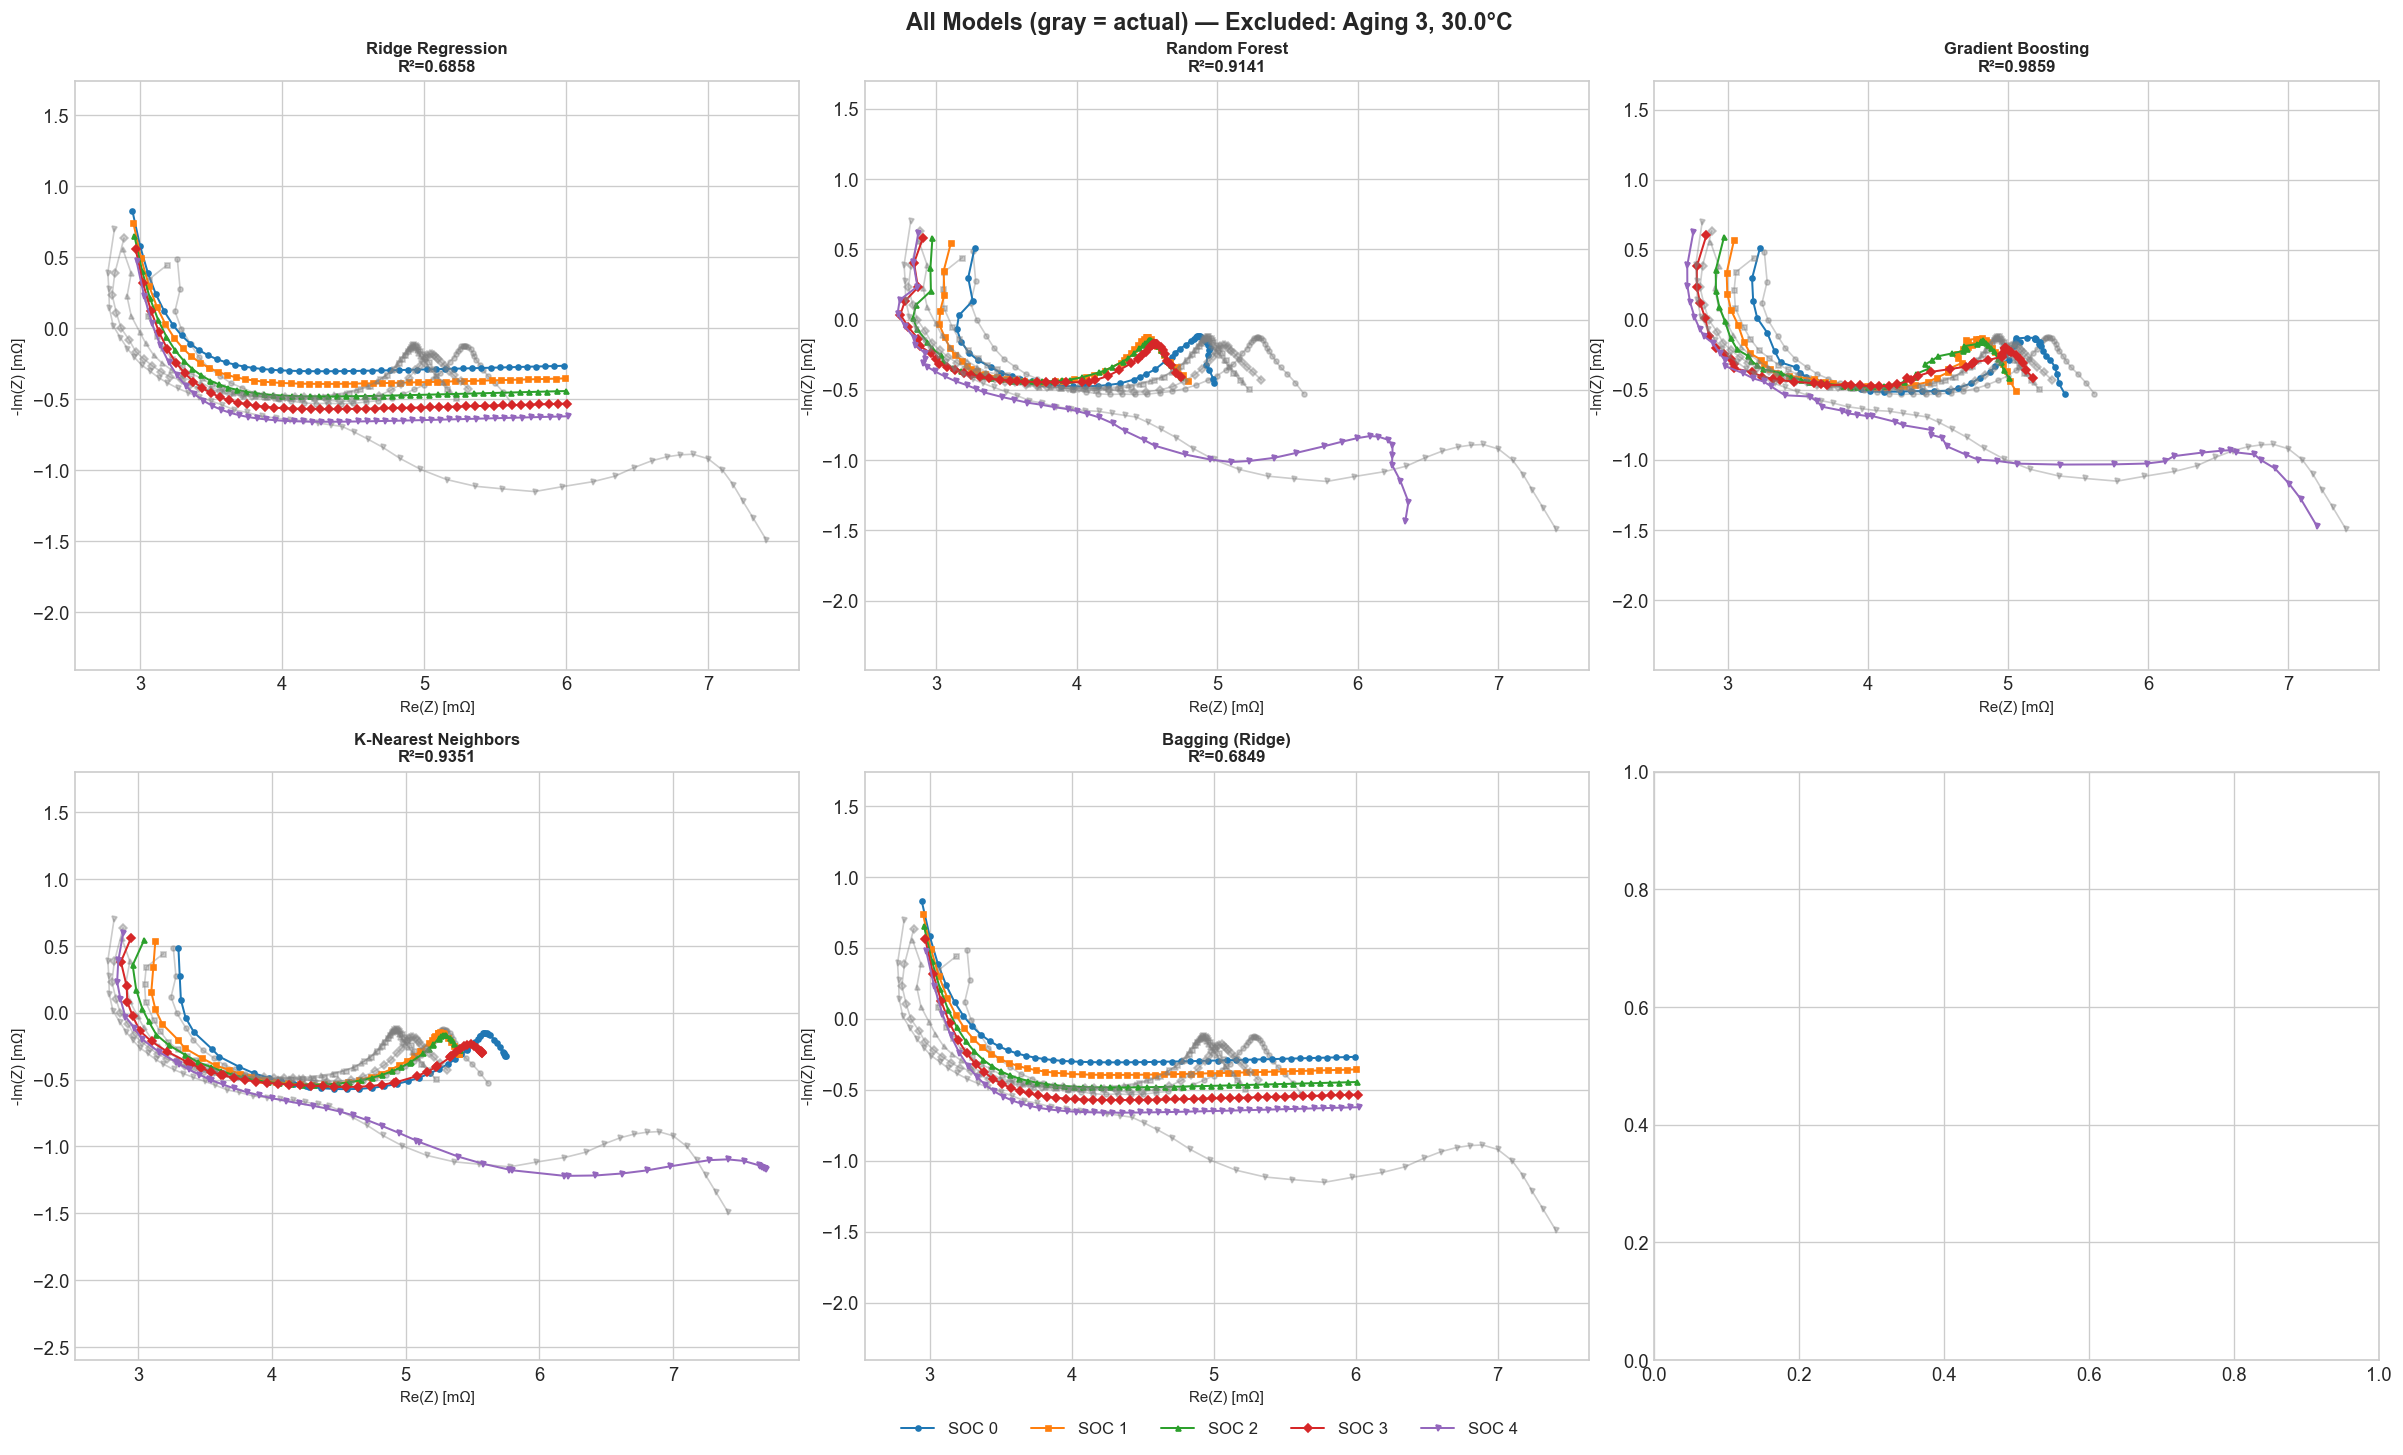

In [13]:
# 9.2 All Models
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes_flat = axes.flatten()

for idx, (name, pred) in enumerate(predictions.items()):
    ax = axes_flat[idx]
    for soc in soc_list:
        mask = df_test['SOC'].values == soc
        # Actual data in gray
        ax.plot(
            y_test[mask, 0], -y_test[mask, 1],
            marker=SOC_MARKERS[soc], markersize=3,
            alpha=0.4, color='gray', linewidth=1
        )
        # Predicted data
        ax.plot(
            pred[mask, 0], -pred[mask, 1],
            marker=SOC_MARKERS[soc], markersize=3,
            linewidth=1.2, label=f'SOC {soc}'
        )
    r2 = results_df[results_df['Model'] == name]['R2_total'].values[0]
    ax.set_title(f'{name}\nR²={r2:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Re(Z) [mΩ]', fontsize=9)
    ax.set_ylabel('-Im(Z) [mΩ]', fontsize=9)
    ax.set_aspect('equal', adjustable='datalim')

# Shared legend
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=5,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    f'All Models (gray = actual) — Excluded: Aging {EXCLUDED_AGING}, {EXCLUDED_TEMP}°C',
    fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.show()

# 10. Hyperparameter Tuning


> **CV strategy & leakage note (Lecture 04 — Testing).**
>
> The held-out evaluation is a *single* (Aging, Temperature) combination, but inside
> `GridSearchCV` we still need a cross-validation splitter. A naive `KFold` on rows
> would mix points from the **same Nyquist curve** into both training and validation
> folds (because every curve contributes ≈ 49 frequencies), inflating scores by
> letting the model interpolate within an already-seen curve.
>
> The correct, leakage-free choice for this task is **`LeaveOneGroupOut`** with
> the group key set to the *(Aging, Temperature)* identifier — exactly mirroring the
> outer hold-out. Each fold pretends one combination is unobserved, just like the
> evaluation does, so cross-validated scores transfer to test scores.
>
> The same logic is implemented in `src/models/tuning.py::tune_task1` and exercised
> by `tests/test_tuning.py`.


In [14]:
print(f"=== HYPERPARAMETER TUNING: {best_model_name} ===\n")

# Parameter grid per model
tuning_configs = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [10, 20],
            "min_samples_leaf": [1, 3]
        }
    },
    "Gradient Boosting": {
        "model": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
        "params": {
            "estimator__n_estimators": [100, 200],
            "estimator__max_depth": [3, 6],
            "estimator__learning_rate": [0.05, 0.1]
        }
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [3, 5, 10, 15, 25],
            "weights": ["uniform", "distance"]
        }
    },
    "Bagging (Ridge)": {
        "model": BaggingRegressor(estimator=Ridge(alpha=1.0), random_state=42),
        "params": {
            "n_estimators": [20, 30, 50],
            "max_samples": [0.6, 0.8, 1.0]
        }
    },
    "Ridge Regression": {
        "model": Ridge(),
        "params": {
            "alpha": [0.01, 0.1, 1, 10, 100]
        }
    },
}

config = tuning_configs[best_model_name]

# --- CV STRATEGY THAT MATCHES THE TEST TASK ---
logo = LeaveOneGroupOut()
groups_train = (
    df_train["Aging"].astype(str) + "_" + df_train["Temperature"].astype(str)
).values

search = GridSearchCV(
    config["model"],
    config["params"],
    cv=logo,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
search.fit(X_train_s, y_train_s, groups=groups_train)

print(f"   Best params: {search.best_params_}")
print(f"   CV folds (LeaveOneGroupOut): {logo.get_n_splits(groups=groups_train)}")

y_pred_tuned = scaler_y.inverse_transform(search.best_estimator_.predict(X_test_s))
mse_tuned = (
    mean_squared_error(y_test[:, 0], y_pred_tuned[:, 0])
    + mean_squared_error(y_test[:, 1], y_pred_tuned[:, 1])
) / 2
r2_tuned = (
    r2_score(y_test[:, 0], y_pred_tuned[:, 0])
    + r2_score(y_test[:, 1], y_pred_tuned[:, 1])
) / 2
mse_orig = results_df.iloc[0]["MSE_total"]

print(f"   Original MSE: {mse_orig:.6f} → Tuned MSE: {mse_tuned:.6f}")
print(f"   Tuned R²: {r2_tuned:.4f}")

if mse_tuned < mse_orig:
    improvement = (mse_orig - mse_tuned) / mse_orig * 100
    print(f"      Improvement: {improvement:.1f}%")
else:
    print(f"   No improvement. Using original model.")

=== HYPERPARAMETER TUNING: Gradient Boosting ===



   Best params: {'estimator__learning_rate': 0.1, 'estimator__max_depth': 6, 'estimator__n_estimators': 200}
   CV folds (LeaveOneGroupOut): 39
   Original MSE: 0.010122 → Tuned MSE: 0.022558
   Tuned R²: 0.9759
   No improvement. Using original model.


# 11. Conclusions

## Pipeline — Parameter-Based Curve Reconstruction (Leave-One-Out)

1. **Setup** — import of libraries.
2. **Data loading** — reading `batteries_cleaned_dataset.csv` from `data/processed/`.
3. **Exploratory Data Analysis** — descriptive statistics, 5×1 grid of Nyquist plots per Aging colored by Temperature, and mean±std trend of `Z_real`/`Z_imag` vs Temperature for each Aging.
4. **Selection of the combination to exclude** — configurable mode (`random` or `manual`): one `Aging × Temperature` combination is fully removed from the training set and reserved as ground truth for validation.
5. **Generation of the 39 Nyquist plots** — 5×8 grid visualizing the training setup: the excluded combination is shown as a placeholder (`? TO PREDICT`), while the remaining 39 are displayed as available training data.
6. **Feature engineering** — 9 physically motivated features: 4 base (`Aging`, `Temperature`, `SOC`, `Frequency`) + `log_Freq` + `inv_Temp` (Arrhenius term) + 3 interaction terms (`Aging×Temp`, `SOC×Temp`, `SOC×Aging`); both `X` and `y` standardized via `StandardScaler`.
7. **Multi-model training** — 5 models: Ridge Regression, Random Forest, Gradient Boosting, K-Nearest Neighbors, Bagging (Ridge). All use native multi-output except Gradient Boosting, which is wrapped in `MultiOutputRegressor` since it does not natively support multiple targets. Metrics (R², MSE, MAE) computed separately for `Z_real`, `Z_imag` and aggregated.
8. **Model comparison** — ranked summary table (by MSE) and 3-panel horizontal bar charts of MSE, MAE and R² for a visual comparison.
9. **Prediction visualization** — best model shown as Actual vs Predicted vs Overlay on Nyquist plane, followed by a 2×3 grid comparing predictions of all 5 models against ground truth.
10. **Hyperparameter tuning** — `GridSearchCV` on the best-ranked model, with a model-specific parameter grid. Cross-validation uses `LeaveOneGroupOut` with `(Aging, Temperature)` as groups, so each CV fold simulates the same extrapolation task as the final test set.

## Comparison with NB2 and NB3

| Metric | Leave-One-Out (NB1) | Classification Ages (NB2) | Aging Interpolation (NB3) |
|---|---|---|---|
| Task | Regression | Classification | Regression |
| Target | Z_real, Z_imag | Young vs Old | Z_real, Z_imag |
| Data excluded | ~245 points (1/40) | 20% group-aware split (`StratifiedGroupKFold`) | ~1960 points — 40 Nyquist plots (1/5) |
| Models benchmarked | 5 | 6 | 5 |
| Difficulty | Medium | Low | **High** |